<a href="https://www.kaggle.com/code/lillynguyen0510/amazon-reviews-classification-4-models?scriptVersionId=332470229" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1. Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-food-reviews-balanced-dataset/Amazon-Food-Reviews.csv


In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from nltk import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from string import punctuation
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

In [3]:
import nltk
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')  # Open Multilingual WordNet
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')  # English Part-of-speech tagger

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

# 2. Data Collection

In [4]:
# Load the dataset
import pandas as pd
df = pd.read_csv('/kaggle/input/amazon-food-reviews-balanced-dataset/Amazon-Food-Reviews.csv')

# Check row and column count
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Print the first few rows of the dataset
df.head(5)

Rows: 241071, Columns: 3


,Score,Summary,Text
0,1,"Great product, terrible price",Do not buy at this price! There are a dozen r...
1,1,Not impressed at ALL,"This product was not HORRIBLE, but I feel chea..."
2,1,Don't order from Amazon!,My dog loves this food and when I saw it here ...
3,1,"Maybe good cracker, but package was damaged","This may be a good cracker, but I had to retur..."
4,1,"Great rice, price is such a rip-off","It is a great product, however, who would spen..."


In [5]:
# De-capitalize the column names
df.columns = df.columns.str.lower()
df.head(5)

,score,summary,text
0,1,"Great product, terrible price",Do not buy at this price! There are a dozen r...
1,1,Not impressed at ALL,"This product was not HORRIBLE, but I feel chea..."
2,1,Don't order from Amazon!,My dog loves this food and when I saw it here ...
3,1,"Maybe good cracker, but package was damaged","This may be a good cracker, but I had to retur..."
4,1,"Great rice, price is such a rip-off","It is a great product, however, who would spen..."


# 3. Data Cleaning & Preprocessing

## Inspect loaded dataset

In [6]:
# Check the data types and non-null counts of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241071 entries, 0 to 241070
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   score    241071 non-null  int64 
 1   summary  241044 non-null  object
 2   text     241071 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.5+ MB


## Handle Missing Values

In [7]:
# Check for missing values in the dataset
missing_values = df.isnull()
print(f"\nMissing values per column:\n{missing_values.sum()}")

# Print rows with missing values
df[missing_values.any(axis=1)]


Missing values per column:
score       0
summary    27
text        0
dtype: int64


,score,summary,text
50212,2,NaN,I only used two maybe three tea bags and got p...
50841,2,NaN,I only used two maybe three tea bags and got p...
51544,2,NaN,I only used two maybe three tea bags and got p...
52446,2,NaN,I only used two maybe three tea bags and got p...
52655,2,NaN,I only used two maybe three tea bags and got p...
55742,2,NaN,I only used two maybe three tea bags and got p...
55977,2,NaN,I only used two maybe three tea bags and got p...
57130,2,NaN,I only used two maybe three tea bags and got p...
57872,2,NaN,I only used two maybe three tea bags and got p...
59398,2,NaN,I only used two maybe three tea bags and got p...


In [8]:
# Create a new copy of the dataset to fill missing values
new_df = df.copy()
new_df.head(5)

,score,summary,text
0,1,"Great product, terrible price",Do not buy at this price! There are a dozen r...
1,1,Not impressed at ALL,"This product was not HORRIBLE, but I feel chea..."
2,1,Don't order from Amazon!,My dog loves this food and when I saw it here ...
3,1,"Maybe good cracker, but package was damaged","This may be a good cracker, but I had to retur..."
4,1,"Great rice, price is such a rip-off","It is a great product, however, who would spen..."


In [9]:
# Get index of rows with missing values in the "summary" column
missing_summary_index = new_df[new_df['summary'].isnull()].index
missing_summary_index

Index([ 50212,  50841,  51544,  52446,  52655,  55742,  55977,  57130,  57872,
        59398,  60209,  60210,  65107,  65230,  66516,  66955,  67755,  69554,
        70693,  72187,  73986,  74375,  75495,  76695,  77285,  82686, 109729],
      dtype='int64')

In [10]:
# Replace missing values in the "summary" columns of type string with values in the "text" column of the same row
new_df.loc[missing_summary_index, 'summary'] = new_df.loc[missing_summary_index, 'text']

In [11]:
# Recheck for missing values in the dataset after filling
print(new_df.isnull().sum())

# Recheck a random missing column to see if value has been replaced
new_df[new_df.index == 50212]

score      0
summary    0
text       0
dtype: int64


,score,summary,text
50212,2,I only used two maybe three tea bags and got p...,I only used two maybe three tea bags and got p...


## Handle duplicated values

In [12]:
# Strip leading and trailing whitespace from the "summary" and "text" columns
new_df['summary'] = new_df['summary'].str.strip()
new_df['text'] = new_df['text'].str.strip()

In [13]:
# Check for duplicate rows in "summary" and "text" columns
duplicates = new_df.duplicated()
print(duplicates.sum())

# Print the first 10 rows of duplicates
new_df[duplicates].sort_values(by='summary').head(10)

57985


,score,summary,text
219901,5,!!!!!!! Flavor review !!!!!!!!,"Best Flavor yet and instant favorite, cant sto..."
195879,5,""" A MIRACLE SUPPLEMENT!!""",I'm a 32 year old man. Construction Electricia...
209781,5,""" A MIRACLE SUPPLEMENT!!""",I'm a 32 year old man. Construction Electricia...
103098,3,"""Best If Used By"" Date","When I received the coffee, the ""best if used ..."
100186,3,"""Best If Used By"" Date","When I received the coffee, the ""best if used ..."
83955,3,"""Best If Used By"" Date","When I received the coffee, the ""best if used ..."
232989,5,"""Better than meat!"" says the carnivore.",I am a card-carrying carnivore. Having said t...
198934,5,"""Better than meat!"" says the carnivore.",I am a card-carrying carnivore. Having said t...
176753,5,"""Better than meat!"" says the carnivore.",I am a card-carrying carnivore. Having said t...
150184,4,"""Bold Coffee""",The Coffee People Jet Fuel K-Cups for Keurig B...


In [14]:
# Assess the duplicated values with value at a specific index (e.g., index 219901) in the "summary" column
new_df[new_df['summary'] == new_df.loc[219901]['summary']]

,score,summary,text
172676,5,!!!!!!! Flavor review !!!!!!!!,"Best Flavor yet and instant favorite, cant sto..."
219901,5,!!!!!!! Flavor review !!!!!!!!,"Best Flavor yet and instant favorite, cant sto..."


In [15]:
# Remove duplicate rows from the dataset, keeping the first occurrence
new_df = new_df.drop_duplicates(keep='last')

# Recheck for duplicate rows in "summary" and "text" columns after removal
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183086 entries, 0 to 241070
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   score    183086 non-null  int64 
 1   summary  183086 non-null  object
 2   text     183086 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.6+ MB


In [16]:
# Recheck for duplicates 
print(new_df.duplicated().sum())

0


# 4. Exploratory Data Analysis (EDA)

In [17]:
# Set figure for all the folllowing plots
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

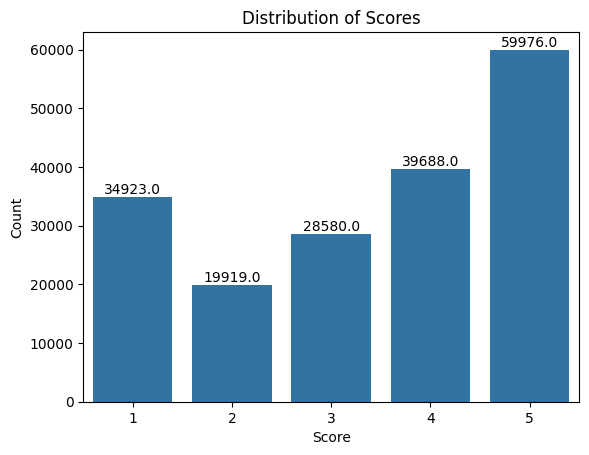

In [18]:
# Assess the distribution of the "score" column
sns.countplot(x='score', data=new_df)
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
# Show number of reviews for each score on the plot
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# 5. Feature Engineering & Selection

In [19]:
# Combine Summary and Text into 1 column 
new_df['total_reviews'] = new_df['summary'] + ". " + new_df['text']

# Drop unnecessary columns
new_df = new_df.reindex(columns=['total_reviews', 'score'])

new_df.head(5)

,total_reviews,score
0,"Great product, terrible price. Do not buy at t...",1
3,"Maybe good cracker, but package was damaged. T...",1
5,No Corn Flavor. A number of other reviewers sa...,1
6,lacks flavor. This mix only makes one round ca...,1
7,Beware of Liquid Nation. This is not a review ...,1


In [20]:
# Convert columns to list
reviews = new_df['total_reviews'].tolist()
scores = new_df['score'].tolist()

# Check the dimension
print(new_df.shape[0])
print(len(reviews))
print(len(scores))

183086
183086
183086


## Word Tokenisation

In [21]:
# Word tokenisation
reviews_tokenized = [] # List to store valid tokenised reviews

scores_final = [] # List to store corresponding final score labels

print('Tokenizing reviews...')

for i in range(len(reviews)):
    
    try:
        tokens = word_tokenize(reviews[i].lower())
        
        if (len(tokens) > 1): # Check for reviews that are empty or consist of 1 word
            
            reviews_tokenized.append(tokens)
            
            scores_final.append(scores[i])
    except:
        pass

print('Done!')

# Check the length of data after tokenisation
print("Total reviews:",len(reviews_tokenized))
print("Total score labels:",len(scores_final),"\n")

# Print the first element of reviews_tokenized
print(reviews_tokenized[0])

Tokenizing reviews...
Done!
Total reviews: 183086
Total score labels: 183086 

['great', 'product', ',', 'terrible', 'price', '.', 'do', 'not', 'buy', 'at', 'this', 'price', '!', 'there', 'are', 'a', 'dozen', 'retailers', ',', 'on', 'line', 'and', 'brick', 'and', 'mortar', ',', 'who', 'sell', 'torani', 'syrups', 'for', 'much', 'less', '.', 'what', 'a', 'rip-off', '!']


In [22]:
# Further word cleaning after tokenisation
stopwords_english = stopwords.words('english')

punctuation_list = list(punctuation)

# Create another copy of reviews_tokenized for further preprocessing and experimentation without affecting the original one

reviews_preprocessed = reviews_tokenized.copy()

print("Continuing removing unnecessary tokens...")

for i in range(len(reviews_tokenized)):
    
    new_tokens = []
    
    for word in reviews_tokenized[i]:
        
        if (word not in punctuation_list) and (word not in stopwords_english): # Remove punctuation and stop words
            
            word = word.replace("-", "")  # Remove hyphens from words
            
            word = word.replace(".", "") # Remove dots from words to normalise abbreviations
            
            regex_check = re.match(f'[a-z]+', word) # Select only tokens that consist of letters from a to z
            
            if regex_check != None:
                
                if regex_check.group() == word:
                    
                    new_tokens.append(word)
                    
    reviews_preprocessed[i] = new_tokens

print('Done!')
    
# Check if pre-processing led to any empty reviews

for i in range(len(reviews_preprocessed)):
    
    if len(reviews_preprocessed[i]) == 0:
        
        print("Review",i,"is empty!")
        
# Print the first element of reviews_preprocessed
        
print(reviews_preprocessed[0])

Continuing removing unnecessary tokens...
Done!
['great', 'product', 'terrible', 'price', 'buy', 'price', 'dozen', 'retailers', 'line', 'brick', 'mortar', 'sell', 'torani', 'syrups', 'much', 'less', 'ripoff']


## Word Lemmatisation

In [23]:
# Initialize the WordNetLemmatizer
wnl = WordNetLemmatizer()

# Define a function to change from  Penn Treebank POS tags to format required by the WordNetLemmatizer
def penn_to_wordnet(penn_pos_tag):
    tag_dictionary = {'NN':'n', 'JJ':'a','VB':'v', 'RB':'r'}
    try:
        return tag_dictionary[penn_pos_tag[:2]]
    except:
        return 'n'

In [24]:
# Word lemmatisation
reviews_lemmatized = [] # List to store lemmatised reviews

for review in reviews_preprocessed:
    pos_tagged_sent = pos_tag(review)
    lemmas = []
    for word, tag in pos_tagged_sent: 
        lemmas.append(wnl.lemmatize(word, pos = penn_to_wordnet(tag)))
    reviews_lemmatized.append(lemmas)
    
# Print the first element of reviews_lemmatized
print(reviews_lemmatized[0])

['great', 'product', 'terrible', 'price', 'buy', 'price', 'dozen', 'retailer', 'line', 'brick', 'mortar', 'sell', 'torani', 'syrups', 'much', 'less', 'ripoff']


In [25]:
# Combine pre-processed words for further processing
dataset = []
for i in range(len(reviews_lemmatized)):
    text = " ".join(reviews_lemmatized[i])
    dataset.append(text)
print(dataset[0])

great product terrible price buy price dozen retailer line brick mortar sell torani syrups much less ripoff


In [26]:
# Split dataset into training set and test set
samples_train, samples_test, scores_train, scores_test = train_test_split(dataset, scores_final, test_size = 0.3, random_state = 2024)

# Check length of training set and test set
no_of_training_samples = len(samples_train)
no_of_test_samples = len(samples_test)
total_samples = no_of_training_samples + no_of_test_samples

print("Total samples:", total_samples)
print("Training samples:", no_of_training_samples, (no_of_training_samples/total_samples)*100,"%")
print("Test samples:", no_of_test_samples, (no_of_test_samples/total_samples)*100,"%")

Total samples: 183086
Training samples: 128160 69.99989076171855 %
Test samples: 54926 30.000109238281464 %


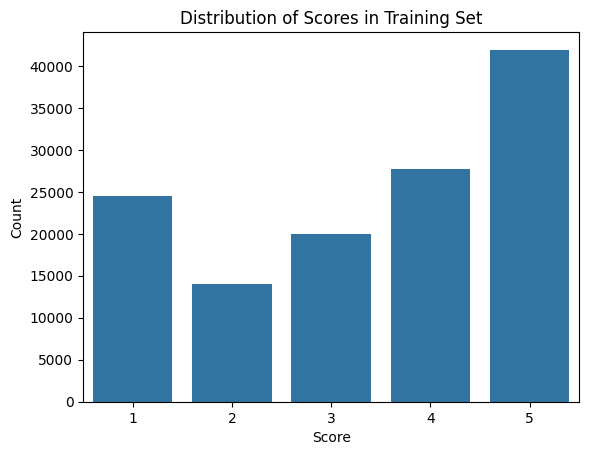

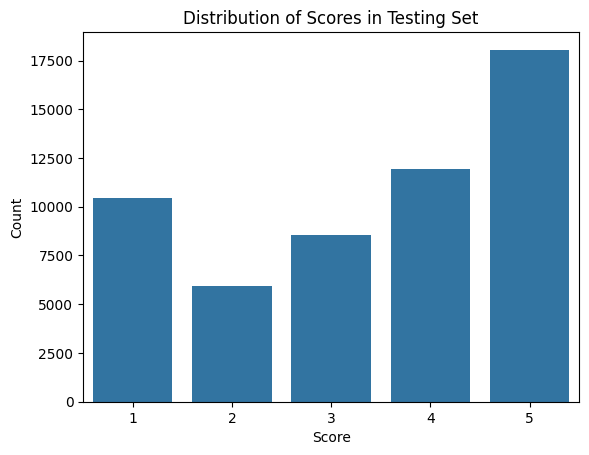

In [27]:
# Review the distribution of the 'score' column in the training and testing set
sns.countplot(x=scores_train)
plt.title('Distribution of Scores in Training Set')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

sns.countplot(x=scores_test)
plt.title('Distribution of Scores in Testing Set')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

# 6. Modelling

In [28]:
# Define a function to compute evaluation metrics
import seaborn as sns
import matplotlib.pyplot as plt

def get_metrics(real_score, prediction):
    # Plot the confusion matrix
    cm = confusion_matrix(real_score, prediction)
    
    sns.heatmap(cm.T, square = True, annot = True, fmt = 'd', xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5],
           cmap = 'Reds')
    
    plt.xlabel('True Label')
    plt.ylabel('Predicted Label')
    plt.show()
    
    print("Accuracy:" , accuracy_score(real_score, prediction))
    print("F1-score:" , f1_score(real_score, prediction, average='macro')) # Get average score for all classes
    print("Precision:" , precision_score(real_score, prediction, average='macro')) # Get average score for all classes
    print("Recall:" , recall_score(real_score, prediction, average='macro')) # Get average score for all classes
    print("\nClassification performance:\n" , classification_report(real_score, prediction))

## Complement Naïve Bayes (Baseline)

Predicted: [5, 1, 1, 4, 4, 5, 5, 5, 3, 1]
Ground truth: [4, 1, 1, 5, 3, 5, 5, 4, 5, 1]




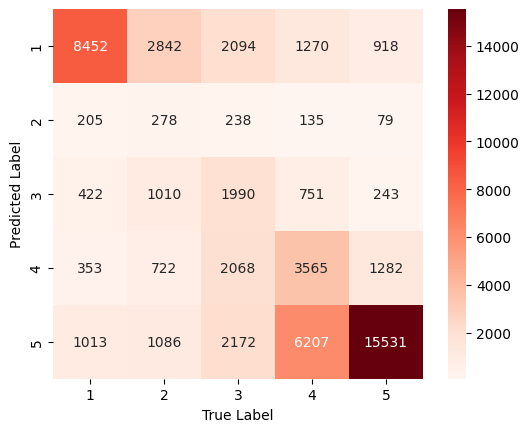

Accuracy: 0.5428394567235918
F1-score: 0.4200254191701111
Precision: 0.466782425603163
Recall: 0.44952145236951147

Classification performance:
               precision    recall  f1-score   support

           1       0.54      0.81      0.65     10445
           2       0.30      0.05      0.08      5938
           3       0.45      0.23      0.31      8562
           4       0.45      0.30      0.36     11928
           5       0.60      0.86      0.70     18053

    accuracy                           0.54     54926
   macro avg       0.47      0.45      0.42     54926
weighted avg       0.50      0.54      0.49     54926



In [29]:
# Naive Bayes model: setting a pipeline where the input is first converted to TF-IDF vectors 
# and then a Complement Naive Bayes is used
NB_model = make_pipeline(TfidfVectorizer(), ComplementNB())

# Train the model on the training data
NB_model.fit(samples_train, scores_train)

# Fit model on the testing data
NB_prediction = NB_model.predict(samples_test)

print("Predicted:",NB_prediction.tolist()[0:10]) # Print the first 10 predictions
print("Ground truth:",scores_test[0:10]) # Print the first 10 ground truth values
print("\n")
# Get evaluation metrics
get_metrics(scores_test, NB_prediction)

## KNN model

In [ ]:
# Load a lightweight model 
# This replace GloVe embeddings with a more efficient and effective sentence embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

NameError: name 'SentenceTransformer' is not defined

In [31]:
# Compute embeddings for training samples
samples_train_embeddings = []

for i in range(len(samples_train)):
    sample_embeddings = model.encode(samples_train[i])
    samples_train_embeddings.append(sample_embeddings)

[-6.35096729e-02 -2.20994130e-02  5.01125865e-02  7.40607753e-02
  1.24099310e-02 -1.62988659e-02 -3.28474119e-03 -6.50903061e-02
 -4.35901023e-02 -7.07126707e-02  9.49876979e-02 -1.13492027e-01
 -2.75428463e-02 -6.54782280e-02  5.77510260e-02 -6.73134178e-02
  1.76637873e-01 -1.13414926e-02 -4.56637591e-02 -1.04298726e-01
 -8.27013236e-03 -4.37010173e-03 -6.65558316e-03 -2.51802076e-02
 -2.90699732e-02  6.19562482e-03  8.97051916e-02  2.19895262e-02
  1.86225008e-02 -1.04497306e-01 -7.61459814e-03  5.63121699e-02
  1.08082073e-04  4.64259461e-02  6.98591443e-03  2.87209768e-02
 -3.65248471e-02 -5.45819849e-02  2.80874651e-02 -1.13957310e-02
 -2.26260703e-02 -7.16232322e-03  7.03366026e-02 -6.13173470e-03
  2.31672358e-02 -4.84213307e-02 -9.87762865e-03 -3.21754590e-02
 -4.05525677e-02 -6.05704598e-02 -2.16042567e-02  5.00864685e-02
 -4.79215309e-02  4.11930308e-02  2.38957368e-02 -1.94535814e-02
 -1.46311238e-01 -6.81253523e-02 -3.54355387e-02  9.23799723e-03
 -6.27810135e-02 -1.50679

In [32]:
# Compute embeddings for testing samples
samples_test_embeddings = []

for i in range(len(samples_test)):
    embeddings = model.encode(samples_test[i])
    samples_test_embeddings.append(embeddings)
    
print(samples_test_embeddings[0].shape)

(384,)


In [33]:
# Define value for k
neighbor = [1,3,5,7]

# Create a dictionary to store k values and their corresponding cross-validation accuracy
cv_score = {}

# Iterate over k
for k in neighbor:
    model = KNeighborsClassifier(n_neighbors = k)
    
    # Get model accuracy using Cross-validation
    cross_val = cross_val_score(model, samples_train_embeddings, scores_train, cv = 10, scoring = 'accuracy')
    cv_score[k] = cross_val.mean() # Add the average cross-validation accuracy to the dictionary

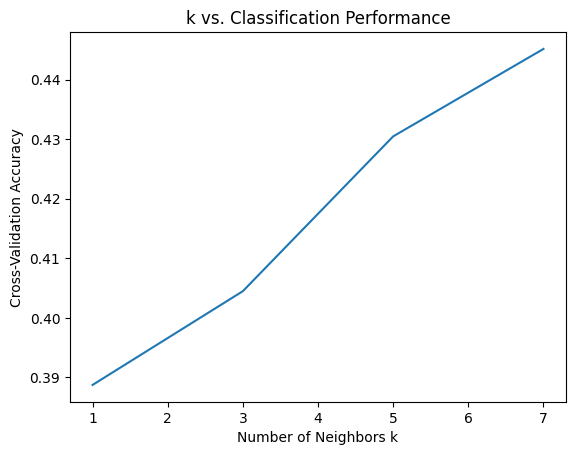

In [34]:
# Plot k and classification performance
plt.plot(neighbor, cv_score.values())
plt.xlabel('Number of Neighbors k')
plt.ylabel('Cross-Validation Accuracy')
plt.title('k vs. Classification Performance')
plt.show()

In [35]:
# Find the best k with highest accuracy
best_k = max(cv_score, key = cv_score.get)

# Train the final model using the best k value
KNN_model = KNeighborsClassifier(n_neighbors = best_k)

# Fit the model using training data
KNN_model.fit(samples_train_embeddings, scores_train)

# Predict on the testing data
KNN_prediction = KNN_model.predict(samples_test_embeddings)

print("Predicted:",KNN_prediction.tolist()[0:10]) # Print the first 10 predictions
print("Ground truth:",scores_test[0:10]) # Print the first 10 ground truth values

Predicted: [1, 2, 5, 1, 4, 5, 5, 5, 1, 1]
Ground truth: [4, 1, 1, 5, 3, 5, 5, 4, 5, 1]


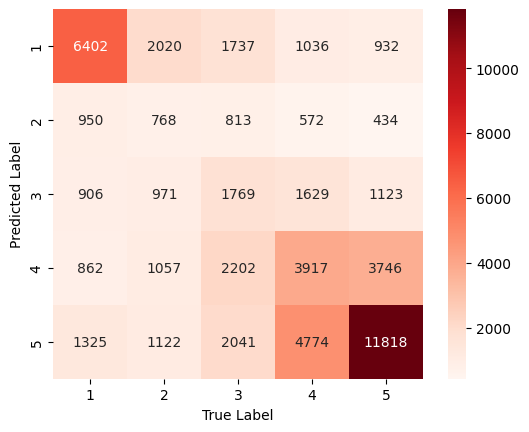

Accuracy: 0.44922259039434875
F1-score: 0.3800464727621278
Precision: 0.3829129578826569
Recall: 0.3863773909219028

Classification performance:
               precision    recall  f1-score   support

           1       0.53      0.61      0.57     10445
           2       0.22      0.13      0.16      5938
           3       0.28      0.21      0.24      8562
           4       0.33      0.33      0.33     11928
           5       0.56      0.65      0.60     18053

    accuracy                           0.45     54926
   macro avg       0.38      0.39      0.38     54926
weighted avg       0.42      0.45      0.43     54926



In [36]:
# Get metrics
get_metrics(scores_test, KNN_prediction)

## Convolutional Neural Network (CNN)

In [ ]:
# Turn the training set and testing set into a NumPy array
X_train = np.array(samples_train)
Y_train = np.array(scores_train) - 1 # NumPy array indexing at 0
X_test = np.array(samples_test)

In [ ]:
# The maximum number of words to be used (most frequent words in the dataset)
max_vocabulary = 20000

# Number of words in each text. All sequences will be padded or truncated to this length.
max_sequence_length = 200

# Create a preprocessing layer which maps text features to integer sequences
vectorize_layer = TextVectorization(max_tokens = max_vocabulary,
                                    output_mode = 'int', # Represent each word in the vocabulary with an integer
                                    output_sequence_length = max_sequence_length)

# Computes a vocabulary of string terms from tokens in a dataset
vectorize_layer.adapt(X_train)

# Check vocabulary length
print("Vocabulary size: " + str(len(vectorize_layer.get_vocabulary())) + " words")

In [ ]:
# Define CNN architecture

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Flatten

embedding_dim = 20 # Size of the word embedding to be used

CNN_model = Sequential(name='MyCNN')

CNN_model.add(vectorize_layer)

# Add Embedding layer

CNN_model.add(Embedding(input_dim=max_vocabulary,
                        output_dim=embedding_dim,
                        input_shape=(max_sequence_length,)))  # Size of the word embedding


CNN_model.add(Flatten())

# First Conv1D layer
CNN_model.add(Conv1D(filters=32, kernel_size=2, activation='relu', padding='same'))

# Add Dropout layer
CNN_model.add(Dropout(0.2))

# Second Conv1D layer
CNN_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))

# Another Dropout layer
CNN_model.add(Dropout(0.2))

# GlobalMaxPooling1D to reduce the dimensions for the Dense layer
CNN_model.add(GlobalMaxPooling1D())

# Output layer which output probability for each class
CNN_model.add(Dense(5, activation='softmax'))

CNN_model.summary()

In [ ]:
# Define hyperparameters

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

epochs = 20
batch_size = 1000
learning_rate = 0.01

opt = Adam(learning_rate = learning_rate) # Initialise Adam optimiser with a leanring rate of 0.01
CNN_model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy']) # Initialise model

# Define early stopping that will stop after 4 epochs if there is no improvement to the accuracy
early_1 = EarlyStopping(monitor = 'val_accuracy', patience = 4, 
                     restore_best_weights = True, mode = 'auto')

# Fit the model
CNN_model_fit = CNN_model.fit(X_train, Y_train,
                   epochs = epochs, batch_size = batch_size, 
                   validation_split = 0.2, # Use 20% of training data as validation data
                   callbacks = [early_1])

In [ ]:
# Predict on the testing data

CNN_prediction = CNN_model.predict(X_test)

# Return the indices of the maximum values along the row and plus 1 to adjust the indices as the trained labels start from 0 to 4

CNN_class_prediction = np.argmax(CNN_prediction, axis = -1) + 1

print("Predicted:",CNN_class_prediction.tolist()[0:10]) # Print the first 10 predictions
print("Ground truth:",scores_test[0:10]) # Print the first 10 ground truth values

In [ ]:
# Get metrics

get_metrics(scores_test, CNN_class_prediction)

## Long Short-Term Memory (LSTM) model

In [ ]:
# Turn training set and testing set into numpy array
import numpy as np

X_train = np.array(samples_train)
Y_train = np.array(scores_train) - 1 # NumPy array indexing at 0
X_test = np.array(samples_test)

In [ ]:
from tensorflow.keras.layers import TextVectorization

# The maximum number of words to be used (most frequent words in the dataset)
max_vocabulary = 20000

# Number of words in each text. All sequences will be padded or truncated to this length.
max_sequence_length = 200

# Create a preprocessing layer which maps text features to integer sequences
vectorize_layer = TextVectorization(max_tokens = max_vocabulary,
                                    output_mode = 'int', # Represent each word in the vocabulary with an integer
                                    output_sequence_length = max_sequence_length)

# Computes a vocabulary of string terms from tokens in a dataset
vectorize_layer.adapt(X_train)

# Check vocabulary length
print("Vocabulary size: " + str(len(vectorize_layer.get_vocabulary())) + " words")

In [ ]:
# Define model architecture 

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, Bidirectional, LSTM

embedding_dim = 20 # Size of the word embedding to be used

LSTM_model = Sequential(name = 'MyLSTM')

LSTM_model.add(Input(shape = (1,), dtype = tf.string))

LSTM_model.add(vectorize_layer)

# Add Embedding layer
LSTM_model.add(Embedding(input_dim = max_vocabulary, # Size of the vocabulary
                   output_dim = embedding_dim, # Size of the word embedding
                    input_length = max_sequence_length)) #length of input sequences

# First BiDirectional LSTM layer. Set return_sequences=True for additional LSTM layer
LSTM_model.add(Bidirectional(LSTM(16, return_sequences = True)))

# Second BiDirectional LSTM layer with Dropout
LSTM_model.add(Bidirectional(LSTM(16, go_backwards=True, dropout=0.2)))

# Output layer which output probability for each class
LSTM_model.add(Dense(5, activation = 'softmax'))

LSTM_model.summary()

In [ ]:
# Define hyperparameters

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

epochs = 20
batch_size = 1000
learning_rate = 0.01

opt = Adam(learning_rate = learning_rate) # Initialise Adam optimiser with a leanring rate of 0.01

LSTM_model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy']) # Initialise model

# Define early stopping that will stop after 4 epochs if there is no improvement to the accuracy
early_2 = EarlyStopping(monitor = 'val_accuracy', patience = 4, 
                     restore_best_weights = True, mode = 'auto')

# Fit the model
LSTM_model_fit = LSTM_model.fit(X_train, Y_train,
                   epochs = epochs, batch_size = batch_size, 
                   validation_split = 0.2, 
                   callbacks = [early_2])

In [ ]:
# Predict on the testing data
LSTM_prediction = LSTM_model.predict(X_test)

# Return the indices of the maximum values along the row and plus 1 to adjust the indices as the trained labels start from 0 to 4
LSTM_class_prediction = np.argmax(LSTM_prediction, axis=-1) + 1

print("Predicted:",LSTM_class_prediction.tolist()[0:10]) # Print the first 10 predictions
print("Ground truth:",scores_test[0:10]) # Print the first 10 ground truth values

In [ ]:
# Get metrics

get_metrics(scores_test, LSTM_class_prediction)